In [ ]:
# Verify the evolve framework is importable (pre-installed via pip install -e ".[dev,tutorials]")
import sys

try:
    import evolve
    print(f"✓ evolve module found at: {evolve.__file__}")
except ImportError as e:
    print(f"✗ Failed to import evolve: {e}")
    print("  Install with: pip install -e '.[dev,tutorials]'")
    sys.exit(1)

# Tutorial 04: GraphGenome and NEAT — Evolving Neural Network Topology

> **Prerequisites**: [Tutorial 01 (UnifiedConfig)](01_unified_config.ipynb) — declarative experiment setup
> **Genome type**: `"graph"` — directed graphs with `input_nodes` and `output_nodes` parameters

## What You'll Learn
- How **topology evolution** discovers network structure and weights simultaneously
- NEAT's speciation mechanism and genomic distance
- Innovation numbers for meaningful crossover between different topologies
- Fitness sharing to maintain population diversity

> **Under the Hood**: This tutorial implements a NEAT-style evolver from scratch to teach topology evolution concepts. The graph genome factory is currently experimental — this tutorial provides the complete internals so you can build custom neuroevolution pipelines.

## Part 1: Setup and Imports

In [ ]:
# Core Python
import sys
import tempfile
import warnings
from collections.abc import Callable
from random import Random
from typing import Any

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Numerical computing
import numpy as np

# Add project root to path
sys.path.insert(0, "../..")

# Evolve framework — declarative configuration

# Evolve framework — graph genome internals (for "under the hood" cells)
# Tutorial utilities
from docs.tutorials.utils.tutorial_utils import (
    # Dataclasses
    check_gpu_available,
    create_island_config,
    # Terminology
    render_mermaid,
)
from evolve.diversity.speciation import neat_distance
from evolve.representation.graph import ConnectionGene, GraphGenome, NodeGene
from evolve.representation.network import sigmoid

warnings.filterwarnings("ignore")
print("✅ All imports successful!")
print(f"NumPy version: {np.__version__}")

✅ All imports successful!
NumPy version: 2.4.2


## Part 2: EA Primer - Evolving Structure (FR-012)

### From Fixed to Variable Topology

| Tutorial | What Evolves | ML Analogy |
|----------|--------------|------------|
| Tutorial 01 | Vector values | Hyperparameter tuning |
| Tutorial 02 | Expression structure | Feature engineering |
| **Tutorial 03** | **Network topology** | **Neural Architecture Search** |

### The Challenge: Competing Conventions

When crossover two different network architectures:
- Which connections correspond?
- How do we align different-sized networks?
- New structures may be initially worse - how do we protect them?

**NEAT's Solution**: Innovation Numbers + Speciation

In [3]:
# Key NEAT terminology
print("🧬 NEAT Terminology\n")
print("=" * 60)
print(f"{'Term':<25} {'ML Analogy':<35}")
print("-" * 60)
neat_terms = [
    ("Innovation Number", "Version control commit ID"),
    ("Node Gene", "Layer/neuron in a network"),
    ("Connection Gene", "Edge with weight (like a synapse)"),
    ("Speciation", "Ensemble of similar architectures"),
    ("Compatibility Distance", "Architecture similarity metric"),
    ("Adjusted Fitness", "Fitness sharing / regularization"),
    ("Stagnation", "Validation loss plateau"),
    ("Add Node Mutation", "Increasing model depth"),
    ("Add Connection Mutation", "Increasing model width/skip connections"),
]
for term, analogy in neat_terms:
    print(f"{term:<25} {analogy:<35}")

🧬 NEAT Terminology

Term                      ML Analogy                         
------------------------------------------------------------
Innovation Number         Version control commit ID          
Node Gene                 Layer/neuron in a network          
Connection Gene           Edge with weight (like a synapse)  
Speciation                Ensemble of similar architectures  
Compatibility Distance    Architecture similarity metric     
Adjusted Fitness          Fitness sharing / regularization   
Stagnation                Validation loss plateau            
Add Node Mutation         Increasing model depth             
Add Connection Mutation   Increasing model width/skip connections


## Part 3: Mermaid Diagrams - NEAT Concepts (FR-014)

📊 NEAT Genome Encoding
Genes encode network structure with innovation numbers for alignment


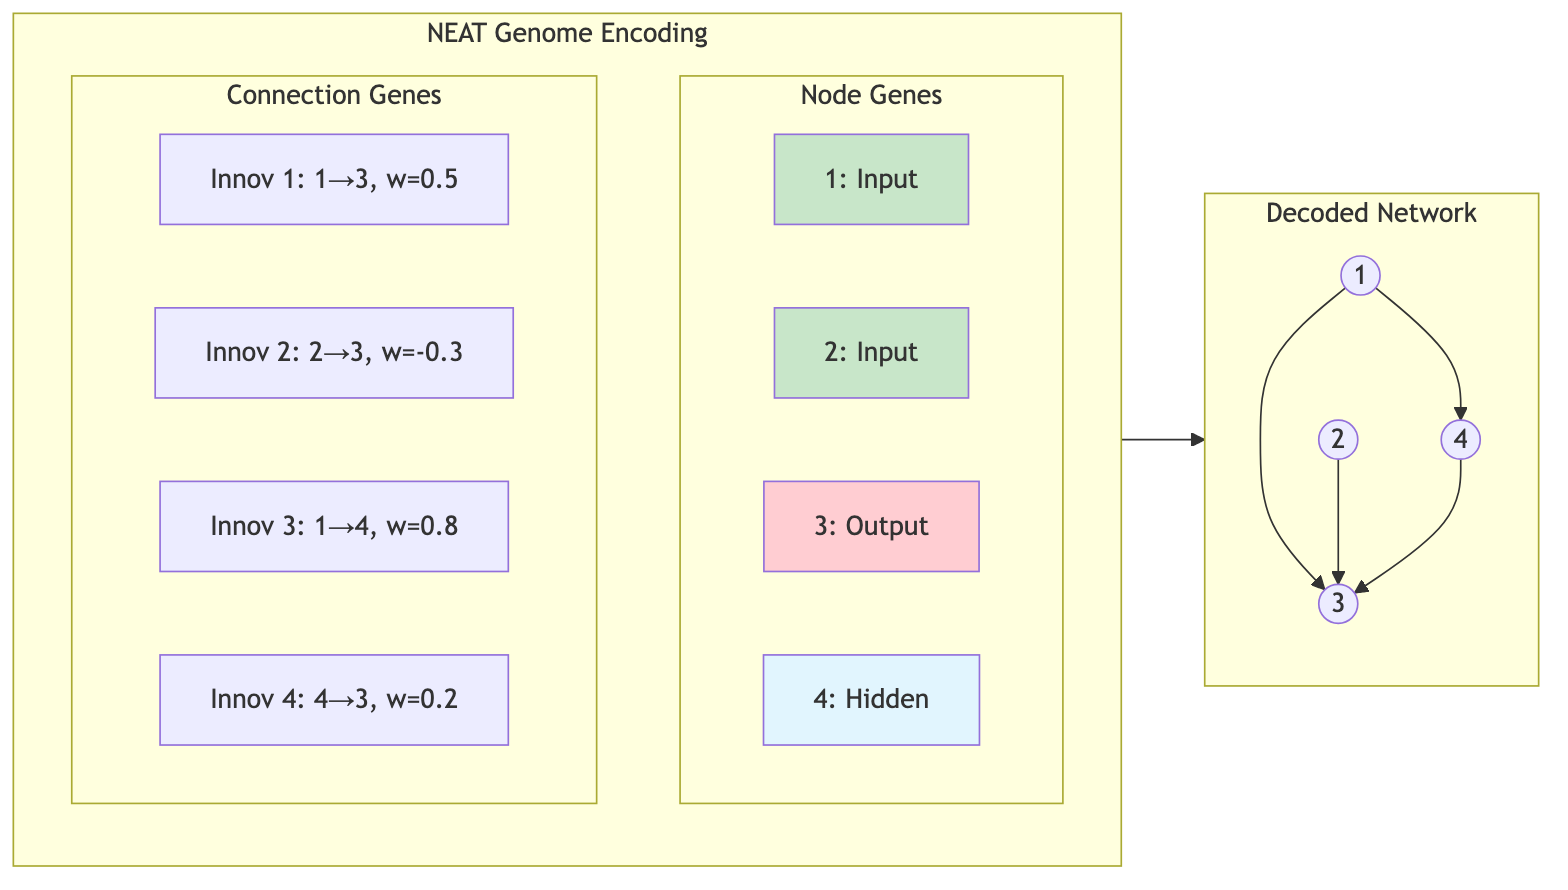

In [4]:
# Diagram 1: NEAT Genome Encoding
NEAT_ENCODING_DIAGRAM = """
graph LR
    subgraph Genome["NEAT Genome Encoding"]
        direction TB
        subgraph Nodes["Node Genes"]
            N1["1: Input"]
            N2["2: Input"]
            N3["3: Output"]
            N4["4: Hidden"]
        end
        subgraph Connections["Connection Genes"]
            C1["Innov 1: 1→3, w=0.5"]
            C2["Innov 2: 2→3, w=-0.3"]
            C3["Innov 3: 1→4, w=0.8"]
            C4["Innov 4: 4→3, w=0.2"]
        end
    end

    subgraph Network["Decoded Network"]
        I1((1)) --> H4((4))
        I1 --> O3((3))
        I2((2)) --> O3
        H4 --> O3
    end

    Genome --> Network

    style N1 fill:#c8e6c9
    style N2 fill:#c8e6c9
    style N3 fill:#ffcdd2
    style N4 fill:#e1f5fe
"""

print("📊 NEAT Genome Encoding")
print("Genes encode network structure with innovation numbers for alignment")
try:
    render_mermaid(NEAT_ENCODING_DIAGRAM)
except Exception:
    print("\nGenome: Node genes (id, type) + Connection genes (innovation, from, to, weight)")
    print("Innovation numbers track when each gene was first created")


📊 Speciation and Fitness Sharing
Species compete for offspring based on adjusted (shared) fitness


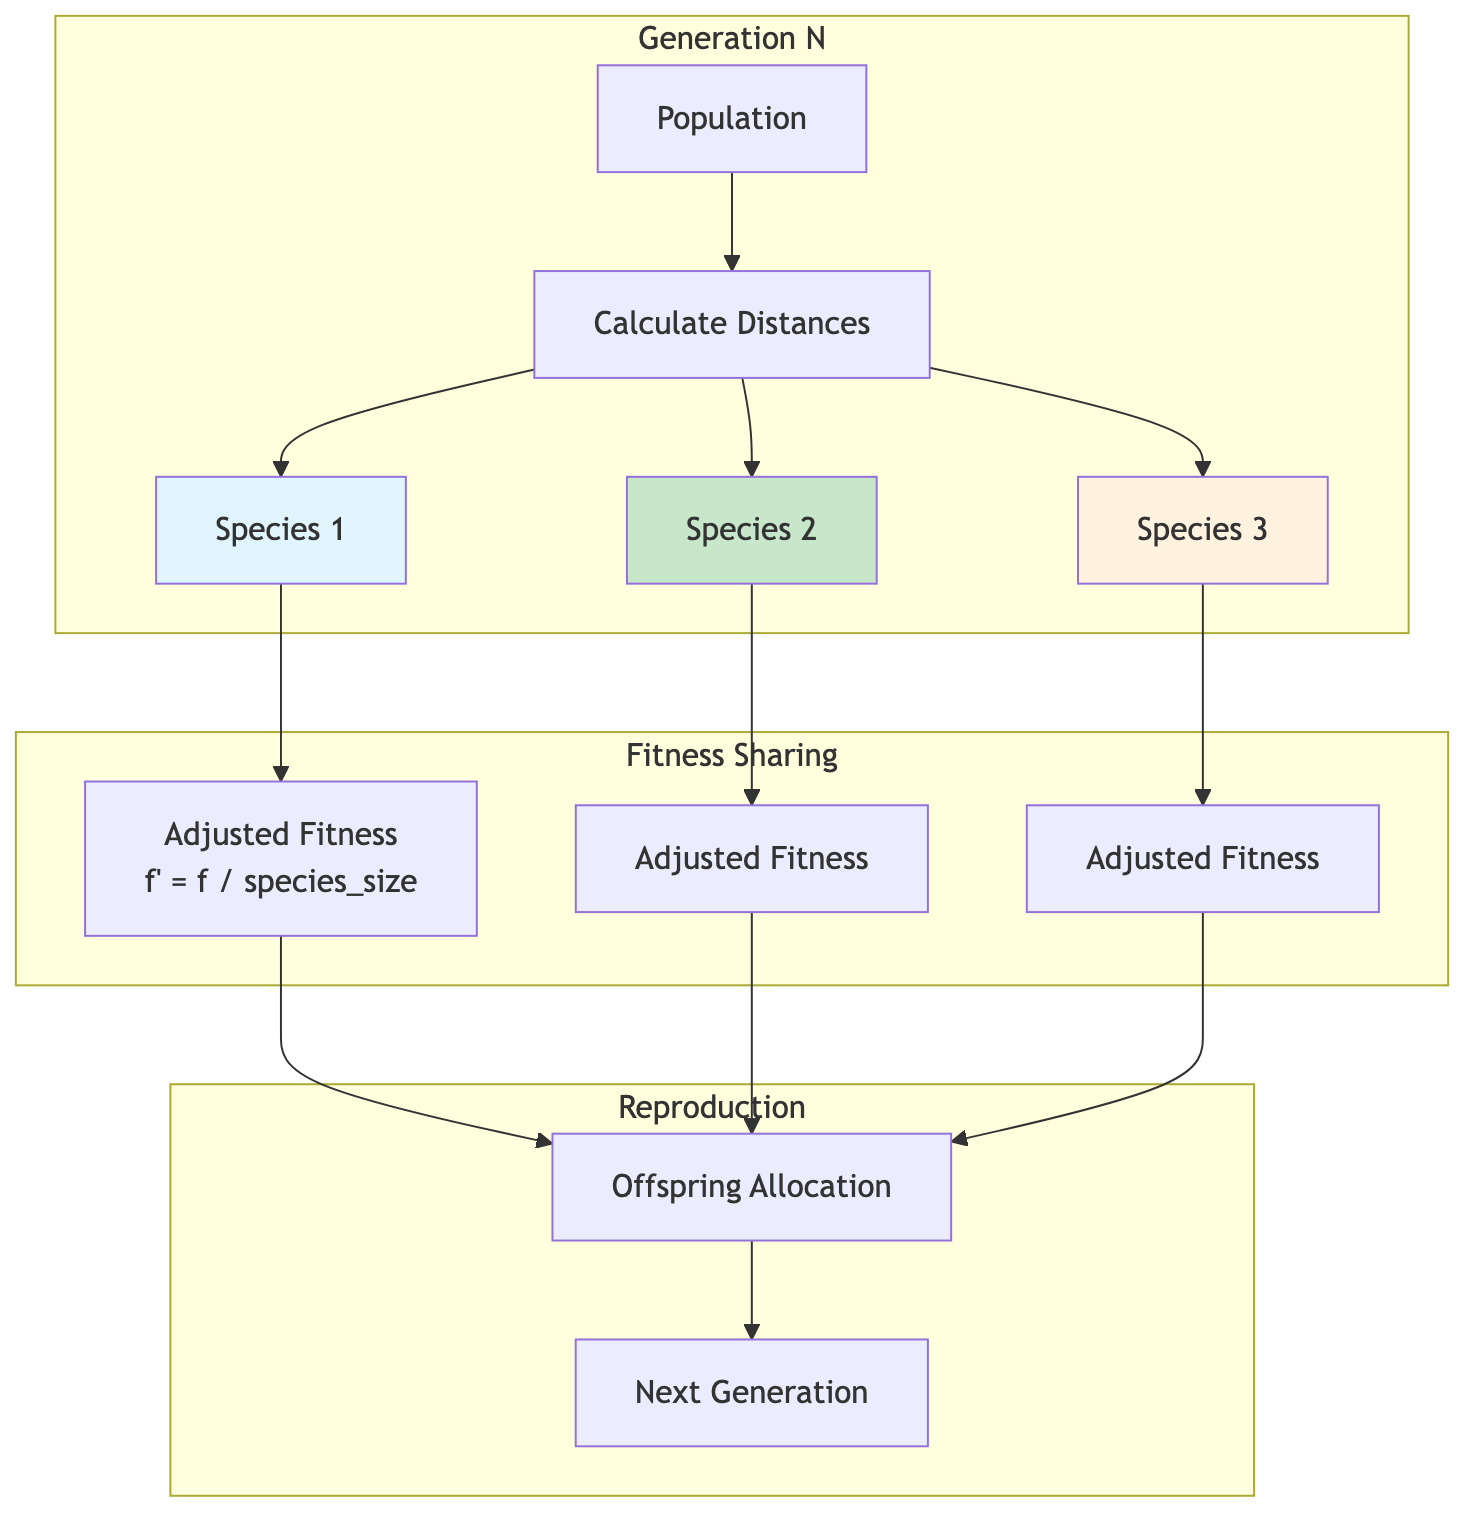

In [5]:
# Diagram 2: Speciation Process
SPECIATION_DIAGRAM = """
graph TD
    subgraph "Generation N"
        P["Population"] --> D["Calculate Distances"]
        D --> S1["Species 1"]
        D --> S2["Species 2"]
        D --> S3["Species 3"]
    end

    subgraph "Fitness Sharing"
        S1 --> AF1["Adjusted Fitness\nf' = f / species_size"]
        S2 --> AF2["Adjusted Fitness"]
        S3 --> AF3["Adjusted Fitness"]
    end

    subgraph "Reproduction"
        AF1 --> R["Offspring Allocation"]
        AF2 --> R
        AF3 --> R
        R --> N["Next Generation"]
    end

    style S1 fill:#e1f5fe
    style S2 fill:#c8e6c9
    style S3 fill:#fff3e0
"""

print("\n📊 Speciation and Fitness Sharing")
print("Species compete for offspring based on adjusted (shared) fitness")
try:
    render_mermaid(SPECIATION_DIAGRAM)
except Exception:
    print("\nProcess: Population → Distance calculation → Species grouping")
    print("         → Fitness sharing within species → Offspring allocation")


📊 NEAT Crossover with Innovation Numbers
Matching genes align, disjoint/excess inherited from fitter parent


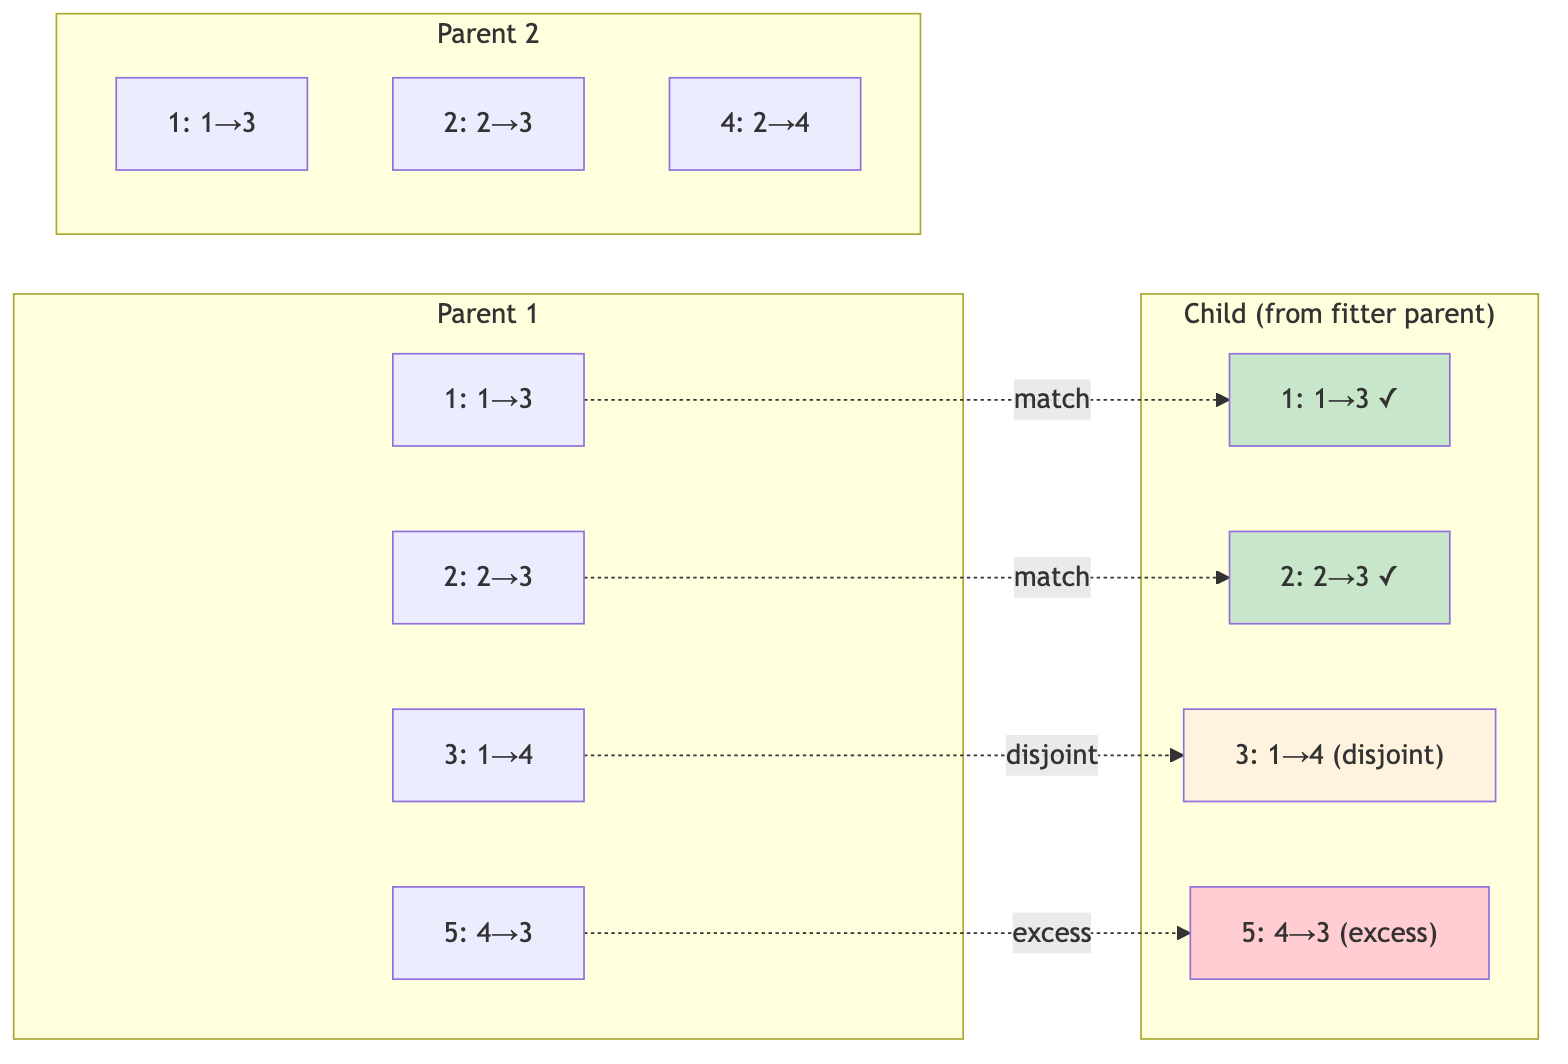

In [6]:
# Diagram 3: Innovation Alignment
CROSSOVER_ALIGNMENT_DIAGRAM = """
graph LR
    subgraph Parent1["Parent 1"]
        P1_1["1: 1→3"]
        P1_2["2: 2→3"]
        P1_3["3: 1→4"]
        P1_5["5: 4→3"]
    end

    subgraph Parent2["Parent 2"]
        P2_1["1: 1→3"]
        P2_2["2: 2→3"]
        P2_4["4: 2→4"]
    end

    subgraph Child["Child (from fitter parent)"]
        C1["1: 1→3 ✓"]
        C2["2: 2→3 ✓"]
        C3["3: 1→4 (disjoint)"]
        C5["5: 4→3 (excess)"]
    end

    P1_1 -.->|match| C1
    P1_2 -.->|match| C2
    P1_3 -.->|disjoint| C3
    P1_5 -.->|excess| C5

    style C1 fill:#c8e6c9
    style C2 fill:#c8e6c9
    style C3 fill:#fff3e0
    style C5 fill:#ffcdd2
"""

print("\n📊 NEAT Crossover with Innovation Numbers")
print("Matching genes align, disjoint/excess inherited from fitter parent")
try:
    render_mermaid(CROSSOVER_ALIGNMENT_DIAGRAM)
except Exception:
    print("\nCrossover alignment:")
    print("- Matching genes (same innovation): randomly inherit from either parent")
    print("- Disjoint genes: inherit from fitter parent")
    print("- Excess genes: inherit from fitter parent")

## Part 4: Problem Setup - XOR Classification

**XOR** is the classic NEAT benchmark because:
- It's NOT linearly separable (requires hidden nodes)
- Minimal networks can solve it (just need 1-2 hidden nodes)
- Easy to verify correctness (4 input patterns)

📊 XOR Problem
Input A    Input B    Output    
----------------------------------------
0          0          0         
0          1          1         
1          0          1         
1          1          0         

⚠️ Key insight: XOR is NOT linearly separable!
   A single-layer network cannot solve it.
   We need at least one hidden node.


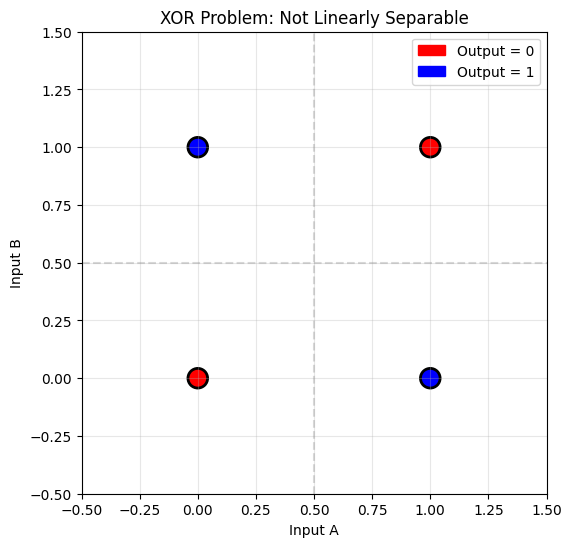

In [7]:
# XOR truth table
XOR_INPUTS = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])

XOR_OUTPUTS = np.array(
    [
        [0.0],  # 0 XOR 0 = 0
        [1.0],  # 0 XOR 1 = 1
        [1.0],  # 1 XOR 0 = 1
        [0.0],  # 1 XOR 1 = 0
    ]
)

print("📊 XOR Problem")
print("=" * 40)
print(f"{'Input A':<10} {'Input B':<10} {'Output':<10}")
print("-" * 40)
for inp, out in zip(XOR_INPUTS, XOR_OUTPUTS):
    print(f"{int(inp[0]):<10} {int(inp[1]):<10} {int(out[0]):<10}")

print("\n⚠️ Key insight: XOR is NOT linearly separable!")
print("   A single-layer network cannot solve it.")
print("   We need at least one hidden node.")

# Visualize
fig, ax = plt.subplots(figsize=(6, 6))
colors = ["red" if y[0] == 0 else "blue" for y in XOR_OUTPUTS]
ax.scatter(XOR_INPUTS[:, 0], XOR_INPUTS[:, 1], c=colors, s=200, edgecolors="black", linewidth=2)
ax.set_xlabel("Input A")
ax.set_ylabel("Input B")
ax.set_title("XOR Problem: Not Linearly Separable")
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.3)
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.3)
ax.legend([mpatches.Patch(color="red"), mpatches.Patch(color="blue")], ["Output = 0", "Output = 1"])
ax.grid(True, alpha=0.3)
plt.show()

## Part 5: NEAT Encoding - Nodes and Connections

In [8]:
class InnovationTracker:
    """
    Tracks innovation numbers for new structural mutations.

    Ensures that the same structural mutation always gets
    the same innovation number, enabling proper crossover alignment.
    """

    def __init__(self, start_innovation: int = 0):
        self.current_innovation = start_innovation
        self.current_node_id = 100  # Start hidden nodes at 100
        # Cache: (from_node, to_node) -> innovation
        self.connection_innovations: dict[tuple[int, int], int] = {}
        # Cache: (split_connection) -> new_node_id
        self.node_splits: dict[int, int] = {}

    def get_connection_innovation(self, from_node: int, to_node: int) -> int:
        """Get or create innovation number for a connection."""
        key = (from_node, to_node)
        if key not in self.connection_innovations:
            self.connection_innovations[key] = self.current_innovation
            self.current_innovation += 1
        return self.connection_innovations[key]

    def get_split_node_id(self, connection_innovation: int) -> int:
        """Get or create node ID for splitting a connection."""
        if connection_innovation not in self.node_splits:
            self.node_splits[connection_innovation] = self.current_node_id
            self.current_node_id += 1
        return self.node_splits[connection_innovation]


# Create minimal XOR genome (no hidden nodes yet)
def create_minimal_genome(tracker: InnovationTracker) -> GraphGenome:
    """
    Create minimal genome: 2 inputs, 1 output, direct connections.
    """
    # Nodes: 2 inputs (0, 1) and 1 output (2)
    nodes = frozenset(
        [
            NodeGene(id=0, node_type="input"),
            NodeGene(id=1, node_type="input"),
            NodeGene(id=2, node_type="output", activation="sigmoid"),
        ]
    )

    # Connections: both inputs to output
    rng = Random(42)
    connections = frozenset(
        [
            ConnectionGene(
                innovation=tracker.get_connection_innovation(0, 2),
                from_node=0,
                to_node=2,
                weight=rng.uniform(-1, 1),
            ),
            ConnectionGene(
                innovation=tracker.get_connection_innovation(1, 2),
                from_node=1,
                to_node=2,
                weight=rng.uniform(-1, 1),
            ),
        ]
    )

    return GraphGenome(
        nodes=nodes,
        connections=connections,
        input_ids=(0, 1),
        output_ids=(2,),
    )


# Create and display
tracker = InnovationTracker()
minimal_genome = create_minimal_genome(tracker)

print("📊 Minimal XOR Genome")
print("=" * 50)
print(
    f"Nodes: {minimal_genome.n_inputs} inputs, {minimal_genome.n_outputs} outputs, {minimal_genome.n_hidden} hidden"
)
print(f"Connections: {minimal_genome.n_connections}")
print("\nNode Genes:")
for node in sorted(minimal_genome.nodes, key=lambda n: n.id):
    print(f"   ID={node.id}, Type={node.node_type}, Activation={node.activation}")
print("\nConnection Genes:")
for conn in sorted(minimal_genome.connections, key=lambda c: c.innovation):
    print(f"   Innovation={conn.innovation}: {conn.from_node}→{conn.to_node}, w={conn.weight:.3f}")

📊 Minimal XOR Genome
Nodes: 2 inputs, 1 outputs, 0 hidden
Connections: 2

Node Genes:
   ID=0, Type=input, Activation=sigmoid
   ID=1, Type=input, Activation=sigmoid
   ID=2, Type=output, Activation=sigmoid

Connection Genes:
   Innovation=0: 0→2, w=0.279
   Innovation=1: 1→2, w=-0.950


## Part 6: Network Visualization (FR-040)

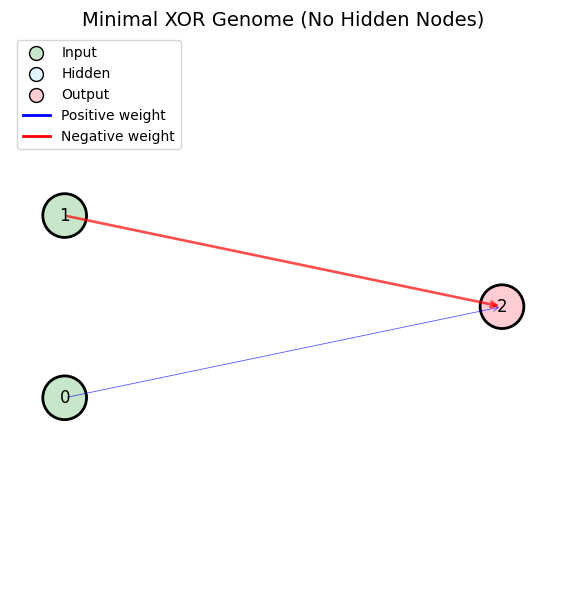


⚠️ This network CANNOT solve XOR!
   It's a linear classifier without hidden nodes.


In [9]:
def visualize_network(genome: GraphGenome, title: str = "NEAT Network"):
    """
    Visualize a NEAT network architecture.

    - Input nodes on left (green)
    - Hidden nodes in middle (blue)
    - Output nodes on right (red)
    - Edge width = |weight|
    - Edge color = red (negative) or blue (positive)
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Calculate positions
    positions = {}

    # Input nodes on left
    n_inputs = len(genome.input_ids)
    for i, node_id in enumerate(sorted(genome.input_ids)):
        y = (i + 1) / (n_inputs + 1)
        positions[node_id] = (0.1, y)

    # Output nodes on right
    n_outputs = len(genome.output_ids)
    for i, node_id in enumerate(sorted(genome.output_ids)):
        y = (i + 1) / (n_outputs + 1)
        positions[node_id] = (0.9, y)

    # Hidden nodes in middle
    hidden_ids = [n.id for n in genome.nodes if n.node_type == "hidden"]
    n_hidden = len(hidden_ids)
    if n_hidden > 0:
        for i, node_id in enumerate(sorted(hidden_ids)):
            x = 0.5
            y = (i + 1) / (n_hidden + 1)
            positions[node_id] = (x, y)

    # Draw connections
    for conn in genome.connections:
        if not conn.enabled:
            continue

        from_pos = positions.get(conn.from_node)
        to_pos = positions.get(conn.to_node)

        if from_pos and to_pos:
            color = "blue" if conn.weight > 0 else "red"
            width = min(abs(conn.weight) * 2, 5)
            alpha = 0.7 if conn.enabled else 0.2
            ax.annotate(
                "",
                xy=to_pos,
                xytext=from_pos,
                arrowprops={"arrowstyle": "->", "color": color, "lw": width, "alpha": alpha},
            )

    # Draw nodes
    for node in genome.nodes:
        pos = positions.get(node.id)
        if pos:
            if node.node_type == "input":
                color = "#c8e6c9"
            elif node.node_type == "output":
                color = "#ffcdd2"
            else:
                color = "#e1f5fe"

            circle = plt.Circle(pos, 0.04, facecolor=color, edgecolor="black", linewidth=2)
            ax.add_patch(circle)
            ax.text(pos[0], pos[1], str(node.id), ha="center", va="center", fontsize=12)

    # Legend
    ax.scatter([], [], c="#c8e6c9", edgecolors="black", s=100, label="Input")
    ax.scatter([], [], c="#e1f5fe", edgecolors="black", s=100, label="Hidden")
    ax.scatter([], [], c="#ffcdd2", edgecolors="black", s=100, label="Output")
    ax.plot([], [], "b-", linewidth=2, label="Positive weight")
    ax.plot([], [], "r-", linewidth=2, label="Negative weight")
    ax.legend(loc="upper left")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=14)

    plt.tight_layout()
    return fig


# Visualize minimal genome
fig = visualize_network(minimal_genome, "Minimal XOR Genome (No Hidden Nodes)")
plt.show()

print("\n⚠️ This network CANNOT solve XOR!")
print("   It's a linear classifier without hidden nodes.")

## Part 7: Genomic Distance and Compatibility (FR-035)

In [10]:
def compute_genomic_distance(
    genome_a: GraphGenome,
    genome_b: GraphGenome,
    c_disjoint: float = 1.0,
    c_excess: float = 1.0,
    c_weight: float = 0.4,
) -> tuple[float, dict[str, Any]]:
    """
    Calculate NEAT compatibility distance with detailed breakdown.

    Distance = (c_excess * E / N) + (c_disjoint * D / N) + (c_weight * W)

    Returns distance and breakdown dict.
    """
    a_innov = {c.innovation: c for c in genome_a.connections}
    b_innov = {c.innovation: c for c in genome_b.connections}

    all_innovations = set(a_innov.keys()) | set(b_innov.keys())

    if not all_innovations:
        return 0.0, {"matching": 0, "disjoint": 0, "excess": 0, "weight_diff": 0}

    max_a = max(a_innov.keys()) if a_innov else 0
    max_b = max(b_innov.keys()) if b_innov else 0
    smaller_max = min(max_a, max_b)

    matching = []
    disjoint = 0
    excess = 0

    for innov in all_innovations:
        in_a = innov in a_innov
        in_b = innov in b_innov

        if in_a and in_b:
            matching.append((a_innov[innov], b_innov[innov]))
        elif innov <= smaller_max:
            disjoint += 1
        else:
            excess += 1

    # Weight difference for matching genes
    if matching:
        weight_diff = sum(abs(a.weight - b.weight) for a, b in matching) / len(matching)
    else:
        weight_diff = 0.0

    # Normalize by larger genome size
    n = max(len(genome_a.connections), len(genome_b.connections), 1)

    distance = c_excess * excess / n + c_disjoint * disjoint / n + c_weight * weight_diff

    breakdown = {
        "matching": len(matching),
        "disjoint": disjoint,
        "excess": excess,
        "weight_diff": weight_diff,
        "n": n,
    }

    return distance, breakdown


# Create two genomes and compare
tracker2 = InnovationTracker()
genome_a = create_minimal_genome(tracker2)

# Create a slightly different genome
genome_b_nodes = frozenset(
    [
        NodeGene(id=0, node_type="input"),
        NodeGene(id=1, node_type="input"),
        NodeGene(id=2, node_type="output", activation="sigmoid"),
        NodeGene(id=100, node_type="hidden", activation="sigmoid"),
    ]
)
genome_b_conns = frozenset(
    [
        ConnectionGene(innovation=0, from_node=0, to_node=2, weight=0.3),
        ConnectionGene(innovation=1, from_node=1, to_node=2, weight=-0.5),
        ConnectionGene(innovation=2, from_node=0, to_node=100, weight=0.8),  # New
        ConnectionGene(innovation=3, from_node=100, to_node=2, weight=0.4),  # New
    ]
)
genome_b = GraphGenome(genome_b_nodes, genome_b_conns, (0, 1), (2,))

distance, breakdown = compute_genomic_distance(genome_a, genome_b)

print("📊 Genomic Distance Calculation")
print("=" * 50)
print(f"Genome A: {genome_a.n_connections} connections")
print(f"Genome B: {genome_b.n_connections} connections")
print("\nBreakdown:")
print(f"   Matching genes:  {breakdown['matching']}")
print(f"   Disjoint genes:  {breakdown['disjoint']}")
print(f"   Excess genes:    {breakdown['excess']}")
print(f"   Avg weight diff: {breakdown['weight_diff']:.4f}")
print(f"\n   Total distance:  {distance:.4f}")

📊 Genomic Distance Calculation
Genome A: 2 connections
Genome B: 4 connections

Breakdown:
   Matching genes:  2
   Disjoint genes:  0
   Excess genes:    2
   Avg weight diff: 0.2356

   Total distance:  0.5942


## Part 8: Compatibility Threshold and Species Assignment (FR-036)

In [11]:
class Speciator:
    """
    Assigns genomes to species based on compatibility distance.
    """

    def __init__(
        self,
        compatibility_threshold: float = 3.0,
        c_disjoint: float = 1.0,
        c_excess: float = 1.0,
        c_weight: float = 0.4,
    ):
        self.compatibility_threshold = compatibility_threshold
        self.c_disjoint = c_disjoint
        self.c_excess = c_excess
        self.c_weight = c_weight
        self.species: list[dict] = []
        self.next_species_id = 0

    def speciate(self, genomes: list[GraphGenome], fitnesses: list[float]) -> list[dict]:
        """
        Assign genomes to species.

        Returns list of species dicts with members and stats.
        """
        # Clear old members but keep representatives
        for sp in self.species:
            sp["members"] = []
            sp["fitnesses"] = []

        # Assign each genome to a species
        for genome, fitness in zip(genomes, fitnesses):
            assigned = False

            for sp in self.species:
                dist = neat_distance(
                    genome, sp["representative"], self.c_disjoint, self.c_excess, self.c_weight
                )
                if dist < self.compatibility_threshold:
                    sp["members"].append(genome)
                    sp["fitnesses"].append(fitness)
                    assigned = True
                    break

            if not assigned:
                # Create new species
                self.species.append(
                    {
                        "id": self.next_species_id,
                        "representative": genome,
                        "members": [genome],
                        "fitnesses": [fitness],
                        "age": 0,
                    }
                )
                self.next_species_id += 1

        # Remove empty species
        self.species = [sp for sp in self.species if sp["members"]]

        # Update representatives (best member of each species)
        for sp in self.species:
            if sp["fitnesses"]:
                best_idx = np.argmax(sp["fitnesses"])
                sp["representative"] = sp["members"][best_idx]
            sp["age"] += 1

        return self.species


print("✅ Speciator class defined")
print("   - Groups genomes by compatibility distance")
print("   - Creates new species when needed")
print("   - Updates species representatives")

✅ Speciator class defined
   - Groups genomes by compatibility distance
   - Creates new species when needed
   - Updates species representatives


## Part 9: Adjusted Fitness (Fitness Sharing) (FR-037)

In [12]:
def calculate_adjusted_fitness(species_list: list[dict]) -> dict[int, float]:
    """
    Calculate adjusted fitness for offspring allocation.

    Adjusted fitness = raw_fitness / species_size

    This protects small species from being overwhelmed.
    """
    adjusted = {}

    for sp in species_list:
        species_size = len(sp["members"])
        if species_size > 0:
            # Sum of adjusted fitnesses for this species
            sp_adjusted = sum(f / species_size for f in sp["fitnesses"])
            adjusted[sp["id"]] = sp_adjusted

    return adjusted


def allocate_offspring(species_list: list[dict], total_offspring: int) -> dict[int, int]:
    """
    Allocate offspring proportional to species adjusted fitness.
    """
    adjusted = calculate_adjusted_fitness(species_list)
    total_adjusted = sum(adjusted.values())

    if total_adjusted == 0:
        # Equal allocation if no fitness variation
        per_species = total_offspring // len(species_list)
        return {sp["id"]: per_species for sp in species_list}

    allocation = {}
    remaining = total_offspring

    for sp in species_list:
        proportion = adjusted.get(sp["id"], 0) / total_adjusted
        count = int(proportion * total_offspring)
        allocation[sp["id"]] = max(1, count)  # At least 1 per species
        remaining -= allocation[sp["id"]]

    # Distribute remaining to best species
    if remaining > 0:
        sorted_species = sorted(species_list, key=lambda s: adjusted.get(s["id"], 0), reverse=True)
        for sp in sorted_species:
            if remaining <= 0:
                break
            allocation[sp["id"]] += 1
            remaining -= 1

    return allocation


# Demonstrate fitness sharing
demo_species = [
    {"id": 0, "members": [None] * 10, "fitnesses": [0.8] * 10},  # Large, good
    {"id": 1, "members": [None] * 3, "fitnesses": [0.9] * 3},  # Small, excellent
    {"id": 2, "members": [None] * 5, "fitnesses": [0.5] * 5},  # Medium, poor
]

print("📊 Fitness Sharing Example")
print("=" * 60)
print(f"{'Species':<10} {'Size':<10} {'Avg Fitness':<15} {'Adjusted':<15}")
print("-" * 60)

adjusted = calculate_adjusted_fitness(demo_species)
for sp in demo_species:
    avg_fit = np.mean(sp["fitnesses"])
    adj = adjusted[sp["id"]]
    print(f"{sp['id']:<10} {len(sp['members']):<10} {avg_fit:<15.3f} {adj:<15.3f}")

print("\nOffspring Allocation (100 total):")
allocation = allocate_offspring(demo_species, 100)
for sp in demo_species:
    print(f"   Species {sp['id']}: {allocation[sp['id']]} offspring")

print("\n💡 Note: Small species with high fitness get protected!")

📊 Fitness Sharing Example
Species    Size       Avg Fitness     Adjusted       
------------------------------------------------------------
0          10         0.800           0.800          
1          3          0.900           0.900          
2          5          0.500           0.500          

Offspring Allocation (100 total):
   Species 0: 37 offspring
   Species 1: 41 offspring
   Species 2: 22 offspring

💡 Note: Small species with high fitness get protected!


## Part 10: Running NEAT Evolution (FR-039)

In [18]:
def decode_network(genome: GraphGenome) -> Callable:
    """
    Decode a GraphGenome into a callable network.

    Uses a simple feedforward evaluation order.
    """
    # Build adjacency and weight matrices
    node_ids = sorted(n.id for n in genome.nodes)
    id_to_idx = {nid: i for i, nid in enumerate(node_ids)}
    n_nodes = len(node_ids)

    weights = np.zeros((n_nodes, n_nodes))
    biases = np.zeros(n_nodes)

    for conn in genome.connections:
        if conn.enabled:
            from_idx = id_to_idx.get(conn.from_node)
            to_idx = id_to_idx.get(conn.to_node)
            if from_idx is not None and to_idx is not None:
                weights[from_idx, to_idx] = conn.weight

    for node in genome.nodes:
        idx = id_to_idx[node.id]
        biases[idx] = node.bias

    input_indices = [id_to_idx[i] for i in genome.input_ids]
    output_indices = [id_to_idx[i] for i in genome.output_ids]

    def forward(inputs: np.ndarray) -> np.ndarray:
        """Forward pass through the network."""
        activations = np.zeros(n_nodes)

        # Set input activations
        for i, inp_idx in enumerate(input_indices):
            activations[inp_idx] = inputs[i]

        # Simple iteration for feedforward (works for acyclic)
        for _ in range(n_nodes):
            new_activations = activations.copy()
            for to_idx in range(n_nodes):
                if to_idx not in input_indices:
                    total = biases[to_idx]
                    for from_idx in range(n_nodes):
                        total += activations[from_idx] * weights[from_idx, to_idx]
                    new_activations[to_idx] = sigmoid(np.array([total]))[0]
            activations = new_activations

        return np.array([activations[i] for i in output_indices])

    return forward


def evaluate_xor(genome: GraphGenome) -> float:
    """
    Evaluate genome on XOR task.

    Fitness = 4 - sum(squared_errors)
    Perfect score = 4.0
    """
    network = decode_network(genome)

    total_error = 0.0
    for inputs, expected in zip(XOR_INPUTS, XOR_OUTPUTS):
        output = network(inputs)
        error = (output[0] - expected[0]) ** 2
        total_error += error

    # Fitness is maximized (4 = perfect)
    return 4.0 - total_error


# Test on minimal genome
fitness = evaluate_xor(minimal_genome)
print(f"Minimal genome XOR fitness: {fitness:.4f} (max 4.0)")
print("\n⚠️ Without hidden nodes, we expect poor performance!")

Minimal genome XOR fitness: 2.9301 (max 4.0)

⚠️ Without hidden nodes, we expect poor performance!


In [14]:
class NEATEvolver:
    """
    NEAT algorithm implementation for XOR.
    """

    def __init__(
        self,
        pop_size: int = 150,
        max_generations: int = 100,
        compatibility_threshold: float = 3.0,
        weight_mutation_rate: float = 0.8,
        weight_perturb_rate: float = 0.9,
        add_node_rate: float = 0.03,
        add_connection_rate: float = 0.05,
        seed: int = 42,
    ):
        self.pop_size = pop_size
        self.max_generations = max_generations
        self.weight_mutation_rate = weight_mutation_rate
        self.weight_perturb_rate = weight_perturb_rate
        self.add_node_rate = add_node_rate
        self.add_connection_rate = add_connection_rate
        self.rng = Random(seed)
        self.np_rng = np.random.default_rng(seed)

        self.tracker = InnovationTracker()
        self.speciator = Speciator(compatibility_threshold=compatibility_threshold)

        self.history = {
            "best_fitness": [],
            "avg_fitness": [],
            "species_count": [],
            "species_sizes": [],  # For stacked area
        }

    def mutate_weights(self, genome: GraphGenome) -> GraphGenome:
        """Mutate connection weights."""
        if not genome.connections:
            return genome

        new_connections = set()
        for conn in genome.connections:
            if self.rng.random() < self.weight_mutation_rate:
                if self.rng.random() < self.weight_perturb_rate:
                    # Perturb existing weight
                    new_weight = conn.weight + self.np_rng.normal(0, 0.5)
                else:
                    # New random weight
                    new_weight = self.np_rng.uniform(-2, 2)
                new_connections.add(conn.with_weight(new_weight))
            else:
                new_connections.add(conn)

        return GraphGenome(
            nodes=genome.nodes,
            connections=frozenset(new_connections),
            input_ids=genome.input_ids,
            output_ids=genome.output_ids,
        )

    def add_node_mutation(self, genome: GraphGenome) -> GraphGenome:
        """Add a node by splitting a connection."""
        enabled_conns = [c for c in genome.connections if c.enabled]
        if not enabled_conns:
            return genome

        # Select connection to split
        conn = self.rng.choice(enabled_conns)

        # Get or create new node ID
        new_node_id = self.tracker.get_split_node_id(conn.innovation)

        # Create new node
        new_node = NodeGene(
            id=new_node_id,
            node_type="hidden",
            activation="sigmoid",
        )

        # Create two new connections
        conn1 = ConnectionGene(
            innovation=self.tracker.get_connection_innovation(conn.from_node, new_node_id),
            from_node=conn.from_node,
            to_node=new_node_id,
            weight=1.0,  # Weight 1 preserves original behavior
        )
        conn2 = ConnectionGene(
            innovation=self.tracker.get_connection_innovation(new_node_id, conn.to_node),
            from_node=new_node_id,
            to_node=conn.to_node,
            weight=conn.weight,
        )

        # Disable old connection
        disabled_conn = conn.with_enabled(False)

        new_nodes = genome.nodes | {new_node}
        new_connections = (genome.connections - {conn}) | {disabled_conn, conn1, conn2}

        return GraphGenome(
            nodes=new_nodes,
            connections=new_connections,
            input_ids=genome.input_ids,
            output_ids=genome.output_ids,
        )

    def add_connection_mutation(self, genome: GraphGenome) -> GraphGenome:
        """Add a new connection between unconnected nodes."""
        # Get all node IDs
        all_ids = [n.id for n in genome.nodes]

        # Existing connections
        existing = {(c.from_node, c.to_node) for c in genome.connections}

        # Possible new connections (no self-loops, no output->anything)
        possible = []
        for from_id in all_ids:
            for to_id in all_ids:
                if from_id == to_id:
                    continue
                if from_id in genome.output_ids:
                    continue  # No connections from outputs
                if to_id in genome.input_ids:
                    continue  # No connections to inputs
                if (from_id, to_id) not in existing:
                    possible.append((from_id, to_id))

        if not possible:
            return genome

        from_id, to_id = self.rng.choice(possible)

        new_conn = ConnectionGene(
            innovation=self.tracker.get_connection_innovation(from_id, to_id),
            from_node=from_id,
            to_node=to_id,
            weight=self.np_rng.uniform(-2, 2),
        )

        return GraphGenome(
            nodes=genome.nodes,
            connections=genome.connections | {new_conn},
            input_ids=genome.input_ids,
            output_ids=genome.output_ids,
        )

    def mutate(self, genome: GraphGenome) -> GraphGenome:
        """Apply all mutations."""
        genome = self.mutate_weights(genome)

        if self.rng.random() < self.add_node_rate:
            genome = self.add_node_mutation(genome)

        if self.rng.random() < self.add_connection_rate:
            genome = self.add_connection_mutation(genome)

        return genome

    def crossover(
        self, parent1: GraphGenome, parent2: GraphGenome, fitness1: float, fitness2: float
    ) -> GraphGenome:
        """NEAT crossover with gene alignment."""
        # Ensure parent1 is fitter
        if fitness2 > fitness1:
            parent1, parent2 = parent2, parent1
            fitness1, fitness2 = fitness2, fitness1

        # Collect genes by innovation
        genes1 = {c.innovation: c for c in parent1.connections}
        genes2 = {c.innovation: c for c in parent2.connections}

        child_connections = []

        for innov in genes1:
            if innov in genes2:
                # Matching gene: randomly choose
                gene = self.rng.choice([genes1[innov], genes2[innov]])
            else:
                # Disjoint/excess: from fitter parent
                gene = genes1[innov]
            child_connections.append(gene)

        # Child gets nodes from fitter parent
        return GraphGenome(
            nodes=parent1.nodes,
            connections=frozenset(child_connections),
            input_ids=parent1.input_ids,
            output_ids=parent1.output_ids,
        )

    def evolve(self) -> GraphGenome:
        """Run NEAT evolution."""
        # Initialize population
        population = [create_minimal_genome(self.tracker) for _ in range(self.pop_size)]

        # Mutate initial population for diversity
        population = [self.mutate(g) for g in population]

        best_ever = None
        best_fitness = -float("inf")

        for gen in range(self.max_generations):
            # Evaluate
            fitnesses = [evaluate_xor(g) for g in population]

            # Track best
            gen_best_idx = np.argmax(fitnesses)
            gen_best_fitness = fitnesses[gen_best_idx]

            if gen_best_fitness > best_fitness:
                best_fitness = gen_best_fitness
                best_ever = population[gen_best_idx]

            # Speciate
            species = self.speciator.speciate(population, fitnesses)

            # Track history
            self.history["best_fitness"].append(gen_best_fitness)
            self.history["avg_fitness"].append(np.mean(fitnesses))
            self.history["species_count"].append(len(species))
            self.history["species_sizes"].append({sp["id"]: len(sp["members"]) for sp in species})

            # Progress
            if gen % 10 == 0 or gen_best_fitness >= 3.9:
                print(f"Gen {gen:3d}: Best={gen_best_fitness:.4f}, Species={len(species)}")

            # Check for solution
            if gen_best_fitness >= 3.9:  # Close enough to perfect
                print(f"\n🎉 Solution found at generation {gen}!")
                break

            # Reproduce
            allocation = allocate_offspring(species, self.pop_size)

            new_population = []
            for sp in species:
                n_offspring = allocation[sp["id"]]

                # Sort by fitness
                sorted_members = sorted(
                    zip(sp["members"], sp["fitnesses"]), key=lambda x: x[1], reverse=True
                )

                # Elitism: keep best
                if sorted_members:
                    new_population.append(sorted_members[0][0])
                    n_offspring -= 1

                # Create offspring
                for _ in range(n_offspring):
                    if len(sorted_members) >= 2 and self.rng.random() < 0.75:
                        # Crossover
                        p1 = self.rng.choice(sorted_members[: max(1, len(sorted_members) // 2)])
                        p2 = self.rng.choice(sorted_members[: max(1, len(sorted_members) // 2)])
                        child = self.crossover(p1[0], p2[0], p1[1], p2[1])
                    else:
                        # Clone
                        child = sorted_members[0][0] if sorted_members else population[0]

                    child = self.mutate(child)
                    new_population.append(child)

            population = new_population[: self.pop_size]

        return best_ever


print("✅ NEATEvolver class defined")

✅ NEATEvolver class defined


In [19]:
# Run NEAT evolution
print("🧬 NEAT Evolution for XOR")
print("=" * 50)

evolver = NEATEvolver(
    pop_size=150,
    max_generations=100,
    compatibility_threshold=3.0,
    add_node_rate=0.03,
    add_connection_rate=0.05,
    seed=42,
)

best_genome = evolver.evolve()

print("\n🏆 Best genome:")
print(f"   Nodes: {len(best_genome.nodes)} ({best_genome.n_hidden} hidden)")
print(f"   Connections: {best_genome.n_enabled_connections} enabled")

🧬 NEAT Evolution for XOR
Gen   0: Best=2.9987, Species=1
Gen  10: Best=3.0000, Species=1
Gen  20: Best=3.0000, Species=1
Gen  30: Best=3.0000, Species=1
Gen  40: Best=3.0000, Species=1
Gen  50: Best=3.0000, Species=1
Gen  60: Best=3.0000, Species=1
Gen  70: Best=3.0000, Species=1
Gen  80: Best=3.0000, Species=1
Gen  90: Best=3.0000, Species=1

🏆 Best genome:
   Nodes: 3 (0 hidden)
   Connections: 0 enabled


## Part 11: Species Visualization (FR-038)

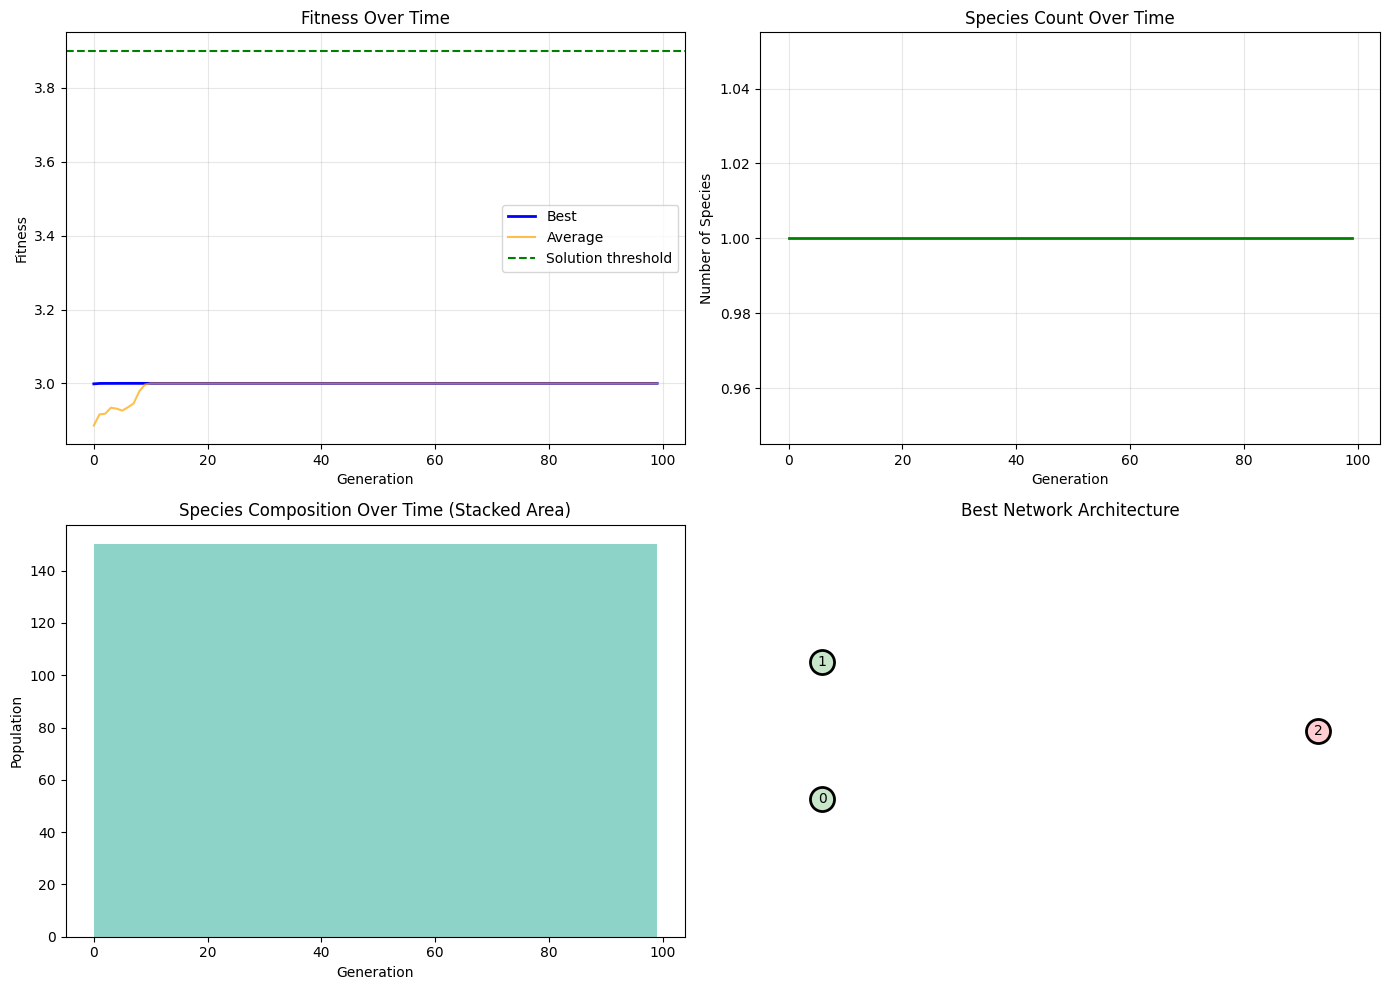

In [20]:
# Plot fitness and species dynamics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

generations = range(len(evolver.history["best_fitness"]))

# Fitness over time
axes[0, 0].plot(generations, evolver.history["best_fitness"], "b-", label="Best", linewidth=2)
axes[0, 0].plot(generations, evolver.history["avg_fitness"], "orange", label="Average", alpha=0.7)
axes[0, 0].axhline(y=3.9, color="green", linestyle="--", label="Solution threshold")
axes[0, 0].set_xlabel("Generation")
axes[0, 0].set_ylabel("Fitness")
axes[0, 0].set_title("Fitness Over Time")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Species count
axes[0, 1].plot(generations, evolver.history["species_count"], "green", linewidth=2)
axes[0, 1].set_xlabel("Generation")
axes[0, 1].set_ylabel("Number of Species")
axes[0, 1].set_title("Species Count Over Time")
axes[0, 1].grid(True, alpha=0.3)

# Species stacked area
if evolver.history["species_sizes"]:
    # Collect all species IDs
    all_species = set()
    for sizes in evolver.history["species_sizes"]:
        all_species.update(sizes.keys())

    # Build data for stacked area
    species_data = {sid: [] for sid in all_species}
    for sizes in evolver.history["species_sizes"]:
        for sid in all_species:
            species_data[sid].append(sizes.get(sid, 0))

    # Stack and plot
    y_stack = np.row_stack([species_data[sid] for sid in sorted(all_species)])
    colors = plt.cm.Set3(np.linspace(0, 1, len(all_species)))
    axes[1, 0].stackplot(generations, y_stack, colors=colors)
    axes[1, 0].set_xlabel("Generation")
    axes[1, 0].set_ylabel("Population")
    axes[1, 0].set_title("Species Composition Over Time (Stacked Area)")

# Visualize best network
ax_net = axes[1, 1]
ax_net.set_title("Best Network Architecture")

# Simple network visualization in the subplot
positions = {}
n_inputs = len(best_genome.input_ids)
for i, node_id in enumerate(sorted(best_genome.input_ids)):
    positions[node_id] = (0.1, (i + 1) / (n_inputs + 1))

n_outputs = len(best_genome.output_ids)
for i, node_id in enumerate(sorted(best_genome.output_ids)):
    positions[node_id] = (0.9, (i + 1) / (n_outputs + 1))

hidden_ids = [n.id for n in best_genome.nodes if n.node_type == "hidden"]
n_hidden = len(hidden_ids)
if n_hidden > 0:
    for i, node_id in enumerate(sorted(hidden_ids)):
        positions[node_id] = (0.5, (i + 1) / (n_hidden + 1))

for conn in best_genome.connections:
    if conn.enabled and conn.from_node in positions and conn.to_node in positions:
        color = "blue" if conn.weight > 0 else "red"
        width = min(abs(conn.weight) * 1.5, 3)
        ax_net.annotate(
            "",
            xy=positions[conn.to_node],
            xytext=positions[conn.from_node],
            arrowprops={"arrowstyle": "->", "color": color, "lw": width, "alpha": 0.6},
        )

for node in best_genome.nodes:
    pos = positions.get(node.id)
    if pos:
        color = {"input": "#c8e6c9", "output": "#ffcdd2", "hidden": "#e1f5fe"}[node.node_type]
        ax_net.scatter(*pos, s=300, c=color, edgecolors="black", linewidth=2, zorder=2)
        ax_net.text(pos[0], pos[1], str(node.id), ha="center", va="center", fontsize=10)

ax_net.set_xlim(0, 1)
ax_net.set_ylim(0, 1)
ax_net.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Verify the solution
print("📊 Solution Verification")
print("=" * 50)

network = decode_network(best_genome)

print(f"{'Input A':<10} {'Input B':<10} {'Expected':<10} {'Output':<10} {'Correct':<10}")
print("-" * 50)

correct = 0
for inputs, expected in zip(XOR_INPUTS, XOR_OUTPUTS):
    output = network(inputs)
    predicted = 1 if output[0] > 0.5 else 0
    is_correct = predicted == int(expected[0])
    correct += is_correct
    status = "✓" if is_correct else "✗"
    print(
        f"{int(inputs[0]):<10} {int(inputs[1]):<10} {int(expected[0]):<10} {output[0]:<10.4f} {status}"
    )

print(f"\nAccuracy: {correct}/4 = {correct / 4 * 100:.1f}%")

📊 Solution Verification
Input A    Input B    Expected   Output     Correct   
--------------------------------------------------
0          0          0          0.5000     ✓
0          1          1          0.5000     ✗
1          0          1          0.5000     ✗
1          1          0          0.5000     ✓

Accuracy: 2/4 = 50.0%


## Part 12: Callbacks (FR-017)

In [22]:
class NEATCallback:
    """Base callback for NEAT evolution."""

    def on_generation_end(
        self, generation: int, species: list[dict], best_genome: GraphGenome, best_fitness: float
    ):
        pass

    def should_stop(self) -> bool:
        return False


class SolutionFoundCallback(NEATCallback):
    """Stop when solution is found."""

    def __init__(self, threshold: float = 3.9):
        self.threshold = threshold
        self._should_stop = False

    def on_generation_end(self, _generation, _species, _best_genome, best_fitness):
        if best_fitness >= self.threshold:
            print(f"\n🎉 Solution found! Fitness {best_fitness:.4f} >= {self.threshold}")
            self._should_stop = True

    def should_stop(self):
        return self._should_stop


class ComplexityMonitorCallback(NEATCallback):
    """Monitor network complexity."""

    def __init__(self):
        self.complexity_history = []

    def on_generation_end(self, generation, _species, best_genome, _best_fitness):
        n_nodes = len(best_genome.nodes)
        n_conns = best_genome.n_enabled_connections
        self.complexity_history.append((n_nodes, n_conns))

        if generation % 20 == 0:
            print(f"   Complexity: {n_nodes} nodes, {n_conns} connections")


print("✅ NEAT Callbacks defined")

✅ NEAT Callbacks defined


## Part 13: Checkpointing (FR-018)

In [23]:
import json


def save_neat_checkpoint(
    population: list[GraphGenome], generation: int, tracker: InnovationTracker, path: str
):
    """Save NEAT evolution checkpoint."""
    checkpoint = {
        "generation": generation,
        "population": [g.to_dict() for g in population],
        "innovation_counter": tracker.current_innovation,
        "node_counter": tracker.current_node_id,
    }
    with open(path, "w") as f:
        json.dump(checkpoint, f, indent=2)
    print(f"💾 NEAT checkpoint saved to {path}")


def load_neat_checkpoint(path: str) -> tuple[list[GraphGenome], int, InnovationTracker]:
    """Load NEAT evolution checkpoint."""
    with open(path) as f:
        checkpoint = json.load(f)

    population = [GraphGenome.from_dict(d) for d in checkpoint["population"]]
    tracker = InnovationTracker(checkpoint["innovation_counter"])
    tracker.current_node_id = checkpoint["node_counter"]

    print(f"📂 NEAT checkpoint loaded: Generation {checkpoint['generation']}")
    return population, checkpoint["generation"], tracker


# Demonstrate
with tempfile.TemporaryDirectory() as tmpdir:
    ckpt_path = os.path.join(tmpdir, "neat_checkpoint.json")

    demo_pop = [create_minimal_genome(InnovationTracker()) for _ in range(3)]
    save_neat_checkpoint(demo_pop, 10, evolver.tracker, ckpt_path)

    loaded_pop, loaded_gen, loaded_tracker = load_neat_checkpoint(ckpt_path)
    print(f"   Loaded {len(loaded_pop)} genomes from generation {loaded_gen}")

💾 NEAT checkpoint saved to /var/folders/_p/9l79gq556sn9ngc796nx7tn40000gn/T/tmpsgp_1v5x/neat_checkpoint.json
📂 NEAT checkpoint loaded: Generation 10
   Loaded 3 genomes from generation 10


## Part 14: Island Model NEAT (FR-020, FR-021, FR-022, FR-023)

In [25]:
print("🏝️ Island Model for NEAT")
print("=" * 50)
print("\nIsland models are especially powerful for NEAT because:")
print("   1. Different islands can evolve different network structures")
print("   2. Migration shares successful topologies")
print("   3. Speciation within islands + structure diversity across islands")
print("\nTypical configuration: 4 islands × 50 individuals each")

# Visualize island topology
island_config = create_island_config(
    num_islands=4,
    population_per_island=50,
    topology="ring",
    migration_rate=0.1,
    migration_interval=10,
)

print("\n📊 Island Configuration:")
print(f"   Islands: {island_config.num_islands}")
print(f"   Total population: {island_config.total_population}")
print(f"   Topology: {island_config.topology}")
print(f"   Migration every {island_config.migration_interval} generations")

🏝️ Island Model for NEAT

Island models are especially powerful for NEAT because:
   1. Different islands can evolve different network structures
   2. Migration shares successful topologies
   3. Speciation within islands + structure diversity across islands

Typical configuration: 4 islands × 50 individuals each

📊 Island Configuration:
   Islands: 4
   Total population: 200
   Topology: ring
   Migration every 10 generations


## Part 15: GPU Acceleration (FR-024, FR-025, FR-026)

In [29]:
# Check GPU availability
gpu_info = check_gpu_available()
gpu_available = gpu_info.get("available", False) if isinstance(gpu_info, dict) else bool(gpu_info)

print("🖥️ GPU Acceleration for NEAT")
print("=" * 50)
print(f"GPU Available: {gpu_available}")
print(f"Info: {gpu_info}")

print("\n📊 What GPU can accelerate in NEAT:")
print("   ✓ Batch network evaluation (forward pass on many inputs)")
print("   ✓ Population fitness evaluation (parallel)")
print("   ✗ Structural mutations (inherently sequential)")
print("   ✗ Speciation (distance calculations can be parallelized)")

if not gpu_available:
    print("\nℹ️ NEAT works efficiently on CPU for moderate population sizes.")
    print("   GPU becomes important for large populations (1000+) or complex networks.")

🖥️ GPU Acceleration for NEAT
GPU Available: False
Info: {'available': False, 'backend': 'cpu', 'device_name': 'CPU', 'message': 'No GPU detected. Running in CPU mode.\nGPU sections will show placeholder benchmarks.\nInstall PyTorch CUDA or JAX with GPU support for acceleration.'}

📊 What GPU can accelerate in NEAT:
   ✓ Batch network evaluation (forward pass on many inputs)
   ✓ Population fitness evaluation (parallel)
   ✗ Structural mutations (inherently sequential)
   ✗ Speciation (distance calculations can be parallelized)

ℹ️ NEAT works efficiently on CPU for moderate population sizes.
   GPU becomes important for large populations (1000+) or complex networks.


## Part 16: Extensions & Next Steps (FR-019)

In [27]:
print("📚 What You've Learned:")
print("=" * 50)
print("1. NEAT evolves both topology AND weights simultaneously")
print("2. Innovation numbers enable crossover between different structures")
print("3. Speciation protects new structures from being overwhelmed")
print("4. Fitness sharing prevents any single structure from dominating")
print("5. XOR requires hidden nodes - NEAT discovers this automatically!")

print("\n🔬 Experiment Ideas:")
experiments = [
    ("Try different compatibility thresholds", "Lower = more species, higher = fewer"),
    ("Adjust mutation rates", "add_node_rate and add_connection_rate"),
    ("Try harder problems", "6-bit parity, pole balancing"),
    ("Visualize innovation flow", "Track which innovations succeed"),
]
for exp, note in experiments:
    print(f"   • {exp}")
    print(f"     {note}")

📚 What You've Learned:
1. NEAT evolves both topology AND weights simultaneously
2. Innovation numbers enable crossover between different structures
3. Speciation protects new structures from being overwhelmed
4. Fitness sharing prevents any single structure from dominating
5. XOR requires hidden nodes - NEAT discovers this automatically!

🔬 Experiment Ideas:
   • Try different compatibility thresholds
     Lower = more species, higher = fewer
   • Adjust mutation rates
     add_node_rate and add_connection_rate
   • Try harder problems
     6-bit parity, pole balancing
   • Visualize innovation flow
     Track which innovations succeed


In [28]:
print("\n📚 Continue Your Learning:")
print("=" * 50)

tutorials = [
    ("Tutorial 01", "VectorGenome", "Continuous optimization basics"),
    ("Tutorial 02", "SequenceGenome", "Variable-length representations, GP"),
    ("Tutorial 04", "RL/Neuroevolution", "Evolving policies for environments"),
    ("Tutorial 05", "SCMGenome", "Causal discovery with multi-objective"),
]

for tutorial, genome, description in tutorials:
    print(f"   {tutorial}: {genome}")
    print(f"      → {description}\n")


📚 Continue Your Learning:
   Tutorial 01: VectorGenome
      → Continuous optimization basics

   Tutorial 02: SequenceGenome
      → Variable-length representations, GP

   Tutorial 04: RL/Neuroevolution
      → Evolving policies for environments

   Tutorial 05: SCMGenome
      → Causal discovery with multi-objective



## Summary

| NEAT Concept | ML Analogy | Purpose |
|--------------|------------|----------|
| **Innovation Number** | Version control | Enables crossover alignment |
| **Speciation** | Ensemble learning | Protects diverse structures |
| **Fitness Sharing** | Regularization | Prevents premature convergence |
| **Add Node** | Increasing depth | Grows network complexity |
| **Add Connection** | Skip connections | Adds representational capacity |

**Key Insight**: NEAT starts minimal and grows complexity only when needed - like progressive neural architecture search!